# Lorenz-96: EnKF-N vs tuned ETKF

## 1. Overview

This tutorial benchmarks the **finite-size ensemble Kalman filter (EnKF-N)**
against a **carefully tuned fixed-inflation ETKF** on a partially observed
60-variable Lorenz-96 model. The point is that EnKF-N reaches accuracy
comparable to the tuned ETKF *without* any prior tuning of a multiplicative
inflation factor: it estimates its anomaly inflation $l_1$ adaptively and
independently at each assimilation cycle.

The fixed inflation $\alpha_*$ used for the ETKF here was selected by a
separate multi-seed tuning script,
`examples/scripts/l96_enkfn_tuning.py`; this notebook only *uses* the
selected value. The paired benchmark script is
`examples/scripts/l96_enkfn.py`. It follows
`docs/contributing/notebook_spec.md`.

## 2. Model

The Lorenz-96 model describes $J$ variables on a periodic ring,

$$
\dot{x}_{j} = (x_{j+1} - x_{j-2})\, x_{j-1} - x_{j} + F,
\qquad j = 1, \dots, J \ (\text{indices mod } J),
$$

with $J = N_{x} = 60$ and forcing $F = 8$, a standard chaotic configuration
(`da.l96.lorenz96`). The forecast map $M$ integrates with fourth-order
Runge-Kutta (`da.scheme.rk4`), time step $\delta t = 0.01$, over one
assimilation window of $n_{\mathrm{obs}} = 5$ steps
($\Delta t_{\mathrm{obs}} = n_{\mathrm{obs}}\,\delta t = 0.05$).

At $N_{x} = 60$ the model has roughly $20$ non-negative Lyapunov exponents, so
a global (unlocalized) ensemble filter needs enough members to span that
unstable-neutral subspace. The representative ensemble size $m = 30$ sits
safely above this threshold; see the Summary for the marginal $m = 25$ case.

## 3. Observation

Observations follow the periodic **2/3 partial-observation pattern**: for each
consecutive triple $(x_{3j}, x_{3j+1}, x_{3j+2})$ the first two components are
observed and the third is left unobserved. With $N_{x} = 60$ this gives
$N_{y} = 40$ observed components. The observation operator $H \in
\mathbb{R}^{N_{y} \times N_{x}}$ is the corresponding row-selection matrix, and

$$
y_{n} = H x_{n} + \varepsilon_{n}, \qquad \varepsilon_{n} \sim N(0, R),
\qquad R = I_{N_{y}},
$$

so the observation-noise scale is
$\sigma_{\mathrm{obs}} = \sqrt{\mathrm{tr}(R)/N_{y}} = 1$.

## 4. DA method

Both filters are ensemble square-root filters built on the ETKF transform.
The forecast uncertainty is an ensemble $X^{f} \in \mathbb{R}^{m \times N_{x}}$
with mean $\bar{x}^{f}$ and anomaly matrix $A^{f}$.

**Forecast step:** each member is propagated by the model,
$x_{n}^{f,(i)} = M(x_{n-1}^{a,(i)})$.

**ETKF analysis (tuned fixed inflation).** With anomaly inflation $\alpha$
applied as $A^{f} \to \alpha A^{f}$ (equivalently $P^{f} \to \alpha^{2} P^{f}$) and
$\tilde{P} = \big[(m-1)\alpha^{-2} I + (H A^{f})^{\top} R^{-1} (H A^{f})\big]^{-1}$,

$$
\bar{x}^{a} = \bar{x}^{f} + A^{f}\, \tilde{P}\, (H A^{f})^{\top} R^{-1}
\,(y - H \bar{x}^{f}),
\qquad
A^{a} = A^{f} \big[(m-1)\, \tilde{P}\big]^{1/2}.
$$

The scalar $\alpha$ is fixed at the preselected $\alpha_*$.

**EnKF-N analysis (adaptive inflation).** EnKF-N replaces the fixed $\alpha$ by
an inflation $l_1$ chosen *per cycle* to account for the sampling error of a
finite ensemble. It minimises a scalar dual cost that balances the innovation
fit against a finite-size hyperprior,

$$
l_1^\star = \arg\min_{l_1 > 0}\ \sum_{k}
\frac{(u_k^{\top} \delta y)^2}{l_1^2 s_k^2 + (m-1)}
\; + \; \varepsilon_N\, l_1^{-2} \; + \; c_L \ln l_1^2,
$$

where $s_k$ and $u_k$ come from the SVD of the whitened forecast anomalies,
$\delta y$ is the whitened innovation, and $(\varepsilon_N, c_L)$ are the
finite-size hyperprior coefficients. The minimiser
$l_1^\star$ is used as the ETKF anomaly inflation for that cycle
($\lambda_{\mathrm{cov}} = (l_1^\star)^2$). The complete hierarchical
derivation, reference equations, normalization, and source mapping are in
[`docs/enkfn.md`](../../docs/enkfn.md). Here we use the package implementation
`da.enkfn.EnKFN` and its stored $l_1$
diagnostics. No EnKF-N hyperparameter is tuned.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| dimension / forcing | $N_{x}$, $F$ | 60, 8 |
| integration step | $\delta t$ | 0.01 |
| steps per window | $n_{\mathrm{obs}}$ | 5 |
| observation interval | $\Delta t_{\mathrm{obs}}$ | 0.05 |
| observation pattern | | periodic 2/3 ($N_{y} = 40$) |
| observation noise | $R$ | $I_{40}$ ($\sigma_{\mathrm{obs}} = 1$) |
| ensemble size | $m$ | 30 |
| assimilation cycles | | 400 |
| spin-up cycles (RMSE averaging) | | 200 |
| tuned ETKF inflation | $\alpha_*$ | 1.08 |
| EnKF-N inflation | $l_1$ | adaptive (per cycle) |
| initial ensemble | | attractor (climatological) sample |
| random seed | | 0 |

$\alpha_* = 1.08$ was selected by the multi-seed ETKF tuning script as the
fixed inflation minimising the seed-averaged post-spin-up RMSE.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.l96 import lorenz96
from da.scheme import rk4
from da.etkf import ETKF
from da.enkfn import EnKFN


def l96_step(x, dt, forcing=8.0):
    return rk4(lorenz96, 0.0, np.asarray(x), (forcing,), dt)


def advance(x, dt, n_steps):
    x = np.asarray(x, dtype=float).copy()
    for _ in range(n_steps):
        x = l96_step(x, dt)
    return x


def rmse(x, truth):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(truth)) ** 2)))


def attractor_ensemble(rng, base, size, dt, spinup=2000, interval=25, pool=1000):
    """Climatological sample from the attractor (cf. examples/scripts/_common.py)."""
    x = advance(base, dt, spinup)
    members = np.empty((pool, len(base)))
    for i in range(pool):
        x = advance(x, dt, interval)
        members[i] = x
    idx = rng.choice(pool, size=size, replace=False)
    return members[idx]


# Parameters (mirror examples/scripts/l96_enkfn.py defaults)
Nx, F = 60, 8.0
dt, obs_interval = 0.01, 5
cycles, spinup = 400, 200
m = 30
alpha_star = 1.08          # selected by the separate ETKF tuning script
seed = 0

# Periodic 2/3 partial-observation operator: observe two of every three sites.
observed = np.array([i for i in range(Nx) if i % 3 != 2])
Ny = observed.size
H = np.zeros((Ny, Nx))
H[np.arange(Ny), observed] = 1.0
R = np.eye(Ny)
sigma_obs = np.sqrt(np.trace(R) / Ny)
print(f'Nx={Nx}, Ny={Ny}, ensemble m={m}, alpha_*={alpha_star}, sigma_obs={sigma_obs:.1f}')

Nx=60, Ny=40, ensemble m=30, alpha_*=1.08, sigma_obs=1.0


## 6. Truth and observations

After a 500-step spin-up onto the attractor, the truth trajectory and the
2/3-partial observations are shown as space-time (Hovmöller) plots. In the
observation panel the unobserved sites are filled with `NaN` (blank columns)
so the partial-observation pattern is visually explicit.

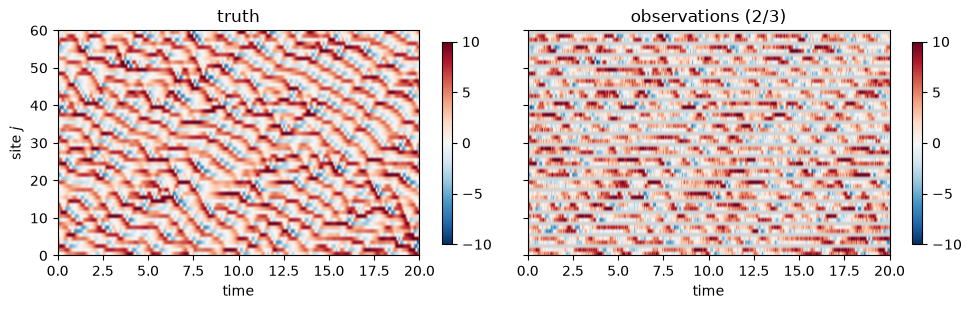

In [2]:
rng = np.random.default_rng(seed)
base = 8.0 * np.ones(Nx)
base[0] += 0.01
x = advance(base, dt, 500)  # spin-up onto the attractor
truth = [x.copy()]
obs = [H @ x + rng.multivariate_normal(np.zeros(Ny), R)]
for _ in range(cycles):
    x = advance(x, dt, obs_interval)
    truth.append(x.copy())
    obs.append(H @ x + rng.multivariate_normal(np.zeros(Ny), R))
truth, obs = np.asarray(truth), np.asarray(obs)
t = np.arange(cycles + 1) * dt * obs_interval

# Place observations on the full (time, site) grid; NaN marks unobserved sites.
obs_full = np.full((cycles + 1, Nx), np.nan)
obs_full[:, observed] = obs

cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad('lightgray')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, field, title in ((axes[0], truth, 'truth'), (axes[1], obs_full, 'observations (2/3)')):
    im = ax.imshow(field.T, aspect='auto', origin='lower', cmap=cmap,
                   vmin=-10, vmax=10, extent=[t[0], t[-1], 0, Nx])
    ax.set_title(title)
    ax.set_xlabel('time')
    fig.colorbar(im, ax=ax, shrink=0.9)
axes[0].set_ylabel('site $j$')
fig.tight_layout()

## 7. Assimilation results

Both filters run on the *same* truth, observations, and initial ensemble. The
tuned ETKF uses the fixed $\alpha_*$; EnKF-N estimates $l_1$ each cycle.

In [3]:
X0 = attractor_ensemble(rng, base, m, dt)

def run(filt):
    filt.initialize(X0.copy())
    means = [filt.X.mean(axis=0)]
    rmses = [rmse(means[0], truth[0])]
    for k in range(1, cycles + 1):
        for _ in range(obs_interval):
            filt.forecast(dt)
        filt.update(obs[k])
        means.append(filt.X.mean(axis=0))
        rmses.append(rmse(means[-1], truth[k]))
    return np.asarray(means), np.asarray(rmses)

etkf_mean, etkf_rmse = run(ETKF(l96_step, H, R, alpha=alpha_star))
enkfn = EnKFN(l96_step, H, R)
enkfn_mean, enkfn_rmse = run(enkfn)
l1 = np.array([d['l1'] for d in enkfn.inflation_diagnostics])

print(f'ETKF  post-spinup mean RMSE: {etkf_rmse[spinup:].mean():.3f}')
print(f'EnKFN post-spinup mean RMSE: {enkfn_rmse[spinup:].mean():.3f}')
print(f'EnKFN mean l1 (post-spinup): {l1[spinup:].mean():.3f}')

ETKF  post-spinup mean RMSE: 0.320
EnKFN post-spinup mean RMSE: 0.326
EnKFN mean l1 (post-spinup): 1.096


### Four-panel Hovmöller comparison

Truth, the 2/3 observations (unobserved sites blank), and the tuned-ETKF and
EnKF-N analysis means on a common colour scale.

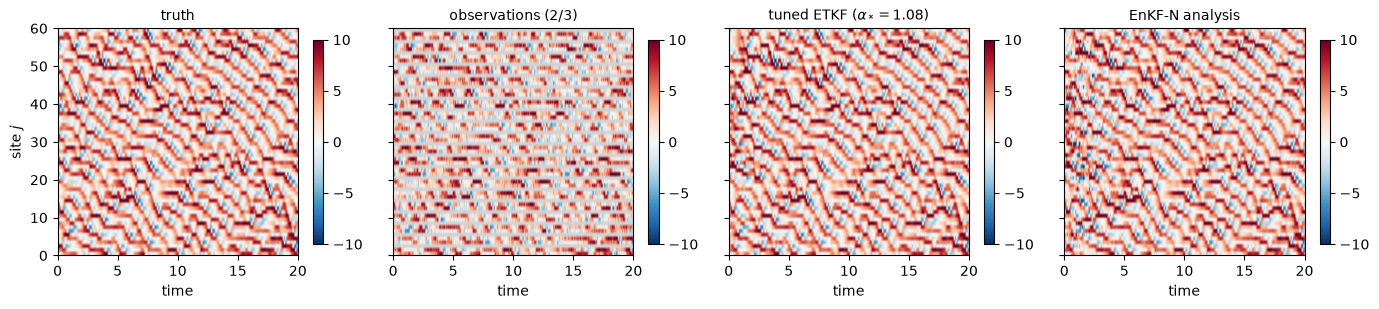

In [4]:
fields = [
    (truth, 'truth', cmap),
    (obs_full, 'observations (2/3)', cmap),
    (etkf_mean, rf'tuned ETKF ($\alpha_*={alpha_star:.2f}$)', plt.get_cmap('RdBu_r')),
    (enkfn_mean, 'EnKF-N analysis', plt.get_cmap('RdBu_r')),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, (field, title, cm) in zip(axes, fields):
    im = ax.imshow(field.T, aspect='auto', origin='lower', cmap=cm,
                   vmin=-10, vmax=10, extent=[t[0], t[-1], 0, Nx])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('time')
    fig.colorbar(im, ax=ax, shrink=0.9)
axes[0].set_ylabel('site $j$')
fig.tight_layout()

## 8. RMSE

Analysis RMSE time series for the tuned ETKF and EnKF-N against the
observation-noise scale $\sigma_{\mathrm{obs}} = 1$, followed by the EnKF-N
adaptive inflation $l_1$ as a standalone time series.

observation noise scale: 1.000
ETKF  post-spinup mean RMSE: 0.320
EnKFN post-spinup mean RMSE: 0.326
EnKFN/ETKF ratio: 1.017


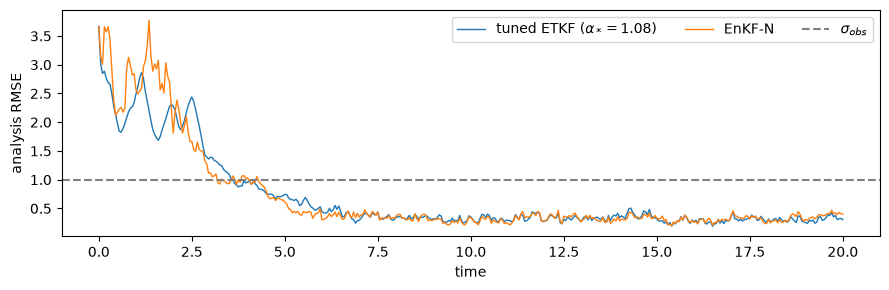

In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, etkf_rmse, color='tab:blue', lw=1, label=rf'tuned ETKF ($\alpha_*={alpha_star:.2f}$)')
ax.plot(t, enkfn_rmse, color='tab:orange', lw=1, label='EnKF-N')
ax.axhline(sigma_obs, color='gray', ls='--', label=r'$\sigma_{obs}$')
ax.set_xlabel('time')
ax.set_ylabel('analysis RMSE')
ax.legend(ncol=3)
fig.tight_layout()

print(f'observation noise scale: {sigma_obs:.3f}')
print(f'ETKF  post-spinup mean RMSE: {etkf_rmse[spinup:].mean():.3f}')
print(f'EnKFN post-spinup mean RMSE: {enkfn_rmse[spinup:].mean():.3f}')
print(f'EnKFN/ETKF ratio: {enkfn_rmse[spinup:].mean() / etkf_rmse[spinup:].mean():.3f}')

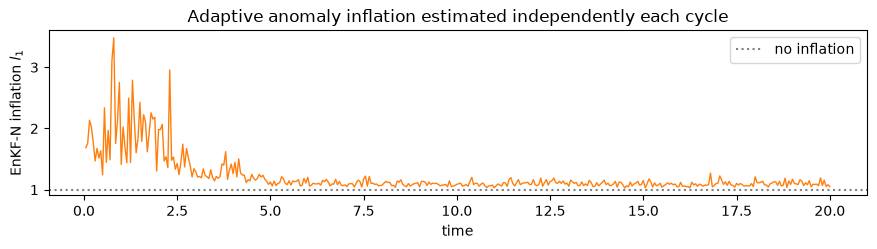

In [6]:
# Standalone EnKF-N adaptive inflation l1 time series.
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(t[1:], l1, color='tab:orange', lw=1)
ax.axhline(1.0, color='gray', ls=':', label='no inflation')
ax.set_xlabel('time')
ax.set_ylabel(r'EnKF-N inflation $l_1$')
ax.set_title('Adaptive anomaly inflation estimated independently each cycle')
ax.legend()
fig.tight_layout()

## 9. Summary

On the $N_{x} = 60$, 2/3-observed Lorenz-96 benchmark with $m = 30$ members, the
EnKF-N analysis RMSE settles near $0.33$, essentially matching the carefully
tuned fixed-inflation ETKF ($\alpha_* = 1.08$) and staying well below the
observation-noise scale $\sigma_{\mathrm{obs}} = 1$. EnKF-N achieves this with
its adaptive inflation settling around $l_1 \approx 1.1$ and **no inflation
tuning at all**, which is the practical advantage the benchmark demonstrates.

The ensemble size matters: $m = 30$ sits above the $\sim 20$-dimensional
unstable-neutral subspace of this model. At the marginal $m = 25$ the global
filter is only borderline stable — whether a given random climatological
ensemble spans the growing directions decides success, so both EnKF-N and the
tuned ETKF diverge for a sizeable fraction of initial ensembles. There, EnKF-N
raises $l_1$ sharply in response to the growing innovations, but a single
global inflation factor cannot supply the missing subspace directions, so it
cannot by itself cure the rank deficiency. Localization (see the LETKF
tutorial) is the standard remedy for smaller ensembles.